# Ridge Regressor Model

In [3]:
import numpy as np  # type: ignore
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import plotly.express as px
import plotly.graph_objects as go
from sklearn.linear_model import Ridge

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


ruta = r'C:\Users\jthow\iCloudDrive\Documents\3_Maestria_Estadistica_UNINORTE\3_Tercer_Semestre\Machine_Learning\tornados.csv.zip'  
df = pd.read_csv(ruta)  
df['loss'] = df['loss'].replace(0, pd.NA)
df['loss'] = df['loss'].interpolate(method='linear')
df['mag'] = df['mag'].fillna(df['mag'].mean())
df.isnull().sum()

om              0
yr              0
mo              0
dy              0
date            0
time            0
tz              0
datetime_utc    0
st              0
stf             0
mag             0
inj             0
fat             0
loss            0
slat            0
slon            0
elat            0
elon            0
len             0
wid             0
ns              0
sn              0
f1              0
f2              0
f3              0
f4              0
fc              0
dtype: int64

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Definir X y y (asegúrate de que ya tienes estas variables previamente definidas)
X = df[['mag', 'slat', 'slon', 'elat', 'elon', 'len', 'wid','f1', 'f2', 'f3', 'f4','loss']]
y = df['inj']

# Dividir los datos en conjunto de entrenamiento y prueba (80% entrenamiento, 20% prueba)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

ridge = Ridge().fit(X_train, y_train)
print("Training set score: {:.2f}".format(ridge.score(X_train, y_train)))
print("Test set score: {:.2f}".format(ridge.score(X_test, y_test)))
# Ver los coeficientes de cada variable en el modelo
coeficientes = pd.Series(ridge.coef_, index=X_train.columns)

# Ver el intercepto del modelo
intercepto = ridge.intercept_

# Mostrar los coeficientes y el intercepto
print("Coeficientes del modelo ridge:")
print(coeficientes)

print("\nIntercepto del modelo ridge:")
print(intercepto)

Training set score: 0.25
Test set score: 0.33
Coeficientes del modelo ridge:
mag     2.102273e+00
slat   -3.674414e-02
slon    8.656891e-04
elat    8.921807e-03
elon    1.167053e-02
len     2.820254e-01
wid     3.326595e-03
f1     -6.830596e-04
f2     -7.113474e-03
f3      1.131799e-02
f4     -2.357629e-03
loss    2.912713e-07
dtype: float64

Intercepto del modelo ridge:
-0.07496725441928809


In [5]:
ridge10 = Ridge(alpha=10).fit(X_train, y_train)
print("Training set score: {:.2f}".format(ridge10.score(X_train, y_train)))
print("Test set score: {:.2f}".format(ridge10.score(X_test, y_test)))
# Ver los coeficientes de cada variable en el modelo
coeficientes = pd.Series(ridge10.coef_, index=X_train.columns)

# Ver el intercepto del modelo
intercepto = ridge10.intercept_

# Mostrar los coeficientes y el intercepto
print("Coeficientes del modelo ridge10:")
print(coeficientes)

print("\nIntercepto del modelo ridge10:")
print(intercepto)

Training set score: 0.25
Test set score: 0.33
Coeficientes del modelo ridge10:
mag     2.101658e+00
slat   -3.674164e-02
slon    8.714776e-04
elat    8.920197e-03
elon    1.167133e-02
len     2.820485e-01
wid     3.327420e-03
f1     -6.830062e-04
f2     -7.112582e-03
f3      1.131728e-02
f4     -2.360622e-03
loss    2.912722e-07
dtype: float64

Intercepto del modelo ridge10:
-0.07414341392181334


In [6]:
ridge01 = Ridge(alpha=0.1).fit(X_train, y_train)
print("Training set score: {:.2f}".format(ridge01.score(X_train, y_train)))
print("Test set score: {:.2f}".format(ridge01.score(X_test, y_test)))

# Ver los coeficientes de cada variable en el modelo
coeficientes = pd.Series(ridge01.coef_, index=X_train.columns)

# Ver el intercepto del modelo
intercepto = ridge01.intercept_

# Mostrar los coeficientes y el intercepto
print("Coeficientes del modelo ridge01:")
print(coeficientes)

print("\nIntercepto del modelo ridge01:")
print(intercepto)

Training set score: 0.25
Test set score: 0.33
Coeficientes del modelo ridge01:
mag     2.102334e+00
slat   -3.674439e-02
slon    8.651101e-04
elat    8.921968e-03
elon    1.167045e-02
len     2.820231e-01
wid     3.326512e-03
f1     -6.830649e-04
f2     -7.113563e-03
f3      1.131806e-02
f4     -2.357329e-03
loss    2.912712e-07
dtype: float64

Intercepto del modelo ridge01:
-0.07504966531273394


In [ ]:
pip install --upgrade seaborn

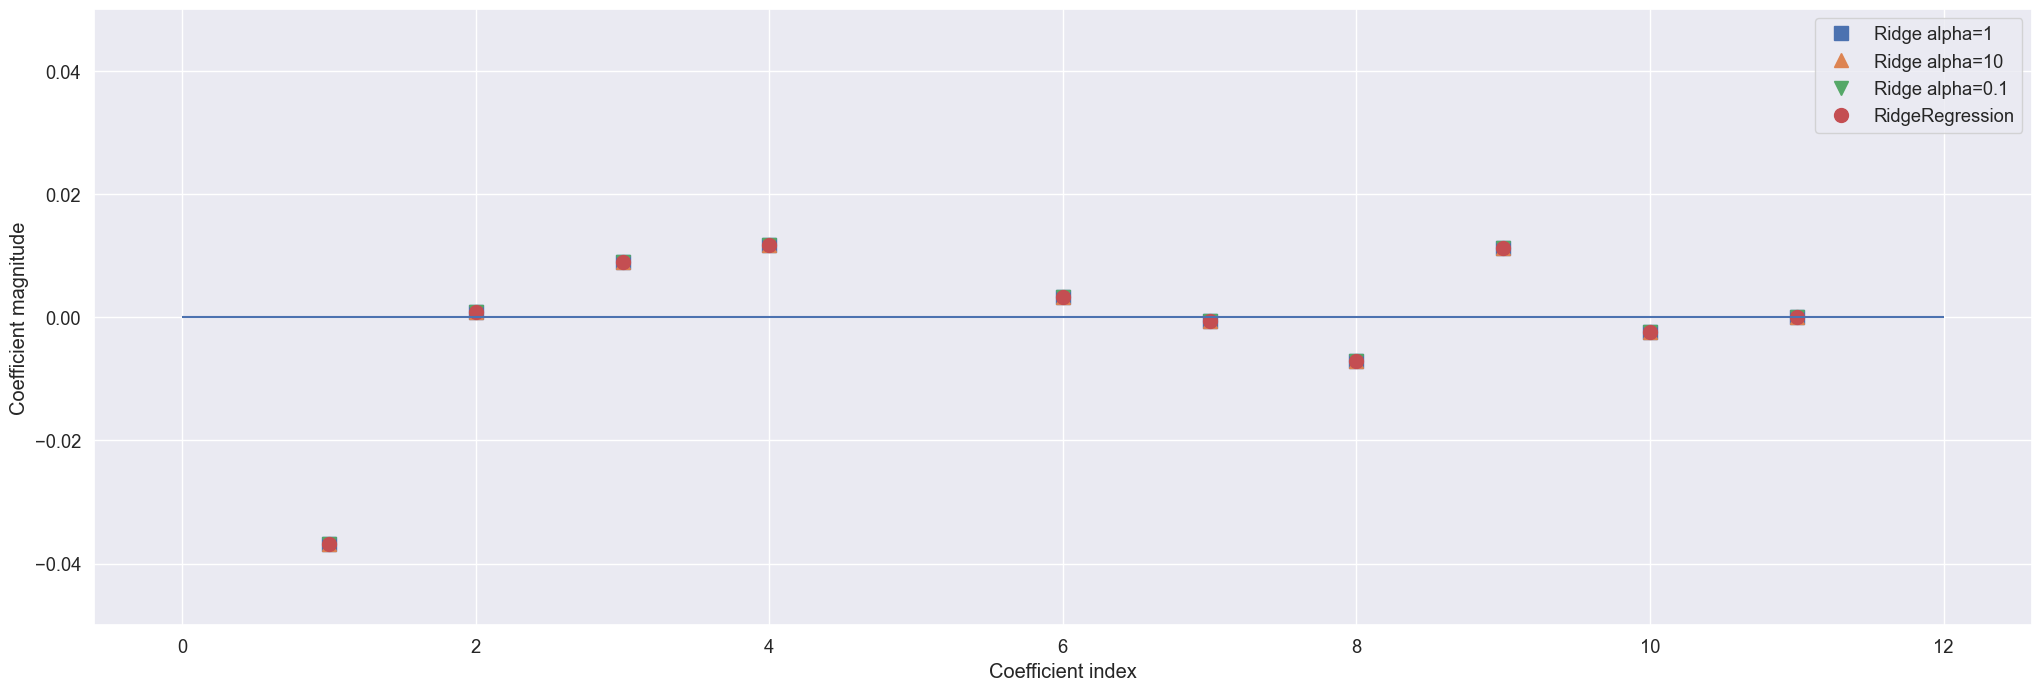

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
import seaborn as sns
sns.set(font_scale=1.2)

# Establecer el tamaño de la fuente
sns.set(font_scale=1.2)

# Crear la figura
plt.figure(figsize=(25, 8))

# Graficar los coeficientes para diferentes modelos
plt.plot(ridge.coef_, 's', label="Ridge alpha=1", markersize=10)  # Tamaño de marcador aumentado
plt.plot(ridge10.coef_, '^', label="Ridge alpha=10", markersize=10)
plt.plot(ridge01.coef_, 'v', label="Ridge alpha=0.1", markersize=10)
plt.plot(ridge01.coef_, 'o', label="RidgeRegression", markersize=10)

# Ajustar las etiquetas y las líneas de referencia
plt.xlabel("Coefficient index")
plt.ylabel("Coefficient magnitude")

# Línea horizontal en y = 0 para visualización
plt.hlines(0, 0, len(ridge01.coef_))

# Ajustar el límite del eje Y
plt.ylim(-0e3, 0e3)  # Ajusta según el rango de los coeficientes (puedes modificar esto)

# Cambiar el eje Y a una escala logarítmica si la disparidad es muy grande
# plt.yscale('symlog')  # Descomenta esta línea si quieres usar una escala logarítmica

# Agregar la leyenda
plt.legend()

# Mostrar el gráfico
plt.show()

## Metricas Ridge Regressor

In [11]:
# ------------------------
# Paso 1: Importar los paquetes necesarios
# ------------------------
import numpy as np
import pandas as pd
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error, r2_score
from statsmodels.stats.diagnostic import acorr_ljungbox
from scipy.stats import jarque_bera
from joblib import dump, load
from time import time

# ------------------------
# Paso 2: Cargar los datos
# ------------------------
# Asegúrate de que esta parte sea correcta para tu caso
# X_train, X_test, y_train, y_test = ...

# ------------------------
# Paso 3: Definir el pipeline y el grid de hiperparámetros
# ------------------------
# Definir el pipeline con un escalador y el modelo Ridge
pipe_ridge = Pipeline([
    ('scaler', StandardScaler()),  # Normalización de los datos
    ('ridge', Ridge())  # Modelo Ridge
])

# Definir el grid de hiperparámetros para Ridge
param_grid_ridge = {
    'ridge__alpha': [0.01, 0.1, 1, 10, 100]  # Valores de penalización
}

# ------------------------
# Paso 4: Entrenar el modelo Ridge con GridSearchCV
# ------------------------
# Crear el objeto GridSearchCV
grid_ridge = GridSearchCV(pipe_ridge, param_grid_ridge, cv=5, n_jobs=-1, scoring='r2')

# Medir el tiempo de entrenamiento
start_time = time()
grid_ridge.fit(X_train, y_train)
training_time_ridge = time() - start_time

# Guardar el modelo entrenado
dump(grid_ridge, 'grid_ridge.joblib')

# ------------------------
# Paso 5: Hacer predicciones con el mejor modelo
# ------------------------
y_pred_ridge = grid_ridge.best_estimator_.predict(X_test)

# ------------------------
# Paso 6: Calcular las métricas del modelo
# ------------------------

# Métricas
mape_ridge = mean_absolute_percentage_error(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
r2_ridge = r2_score(y_test, y_pred_ridge)

# Ljung-Box p-value
lb_p_value_ridge = acorr_ljungbox(y_test - y_pred_ridge, lags=[10], return_df=True)['lb_pvalue'].iloc[0]

# Jarque-Bera p-value
jb_p_value_ridge = jarque_bera(y_test - y_pred_ridge)[1]

# ------------------------
# Paso 7: Crear DataFrame con los resultados
# ------------------------
resultados_ridge = pd.DataFrame({
    'Modelo': ['Ridge Regressor optimizado (GridSearchCV)'],
    'MAPE': [f"{mape_ridge:.2f}"],
    'RMSE': [f"{rmse_ridge:.2f}"],
    'R Cuadrado': [f"{r2_ridge:.2f}"],
    'Ljung-Box p-value': [f"{lb_p_value_ridge:.2f}" if 'lb_p_value_ridge' in locals() else None],
    'Jarque-Bera p-value': [f"{jb_p_value_ridge:.2f}"],
    'CPU time (s)': [round(training_time_ridge, 2)]
})

# ------------------------
# Paso 8: Mostrar los resultados
# ------------------------
print("Métricas para el modelo Ridge Regressor:")
display(resultados_ridge)


Métricas para el modelo Ridge Regressor:


,Modelo,MAPE,RMSE,R Cuadrado,Ljung-Box p-value,Jarque-Bera p-value,CPU time (s)
0,Ridge Regressor optimizado (GridSearchCV),8943370414620937.00,18.83,0.33,0.93,0.00,4.84
